Dataset loaded successfully!

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0   

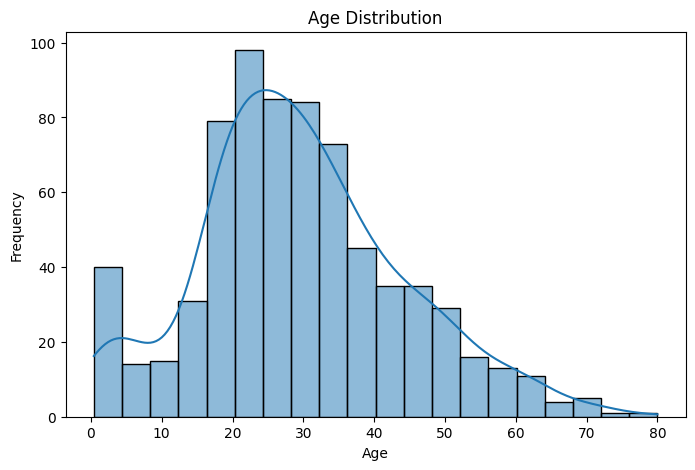

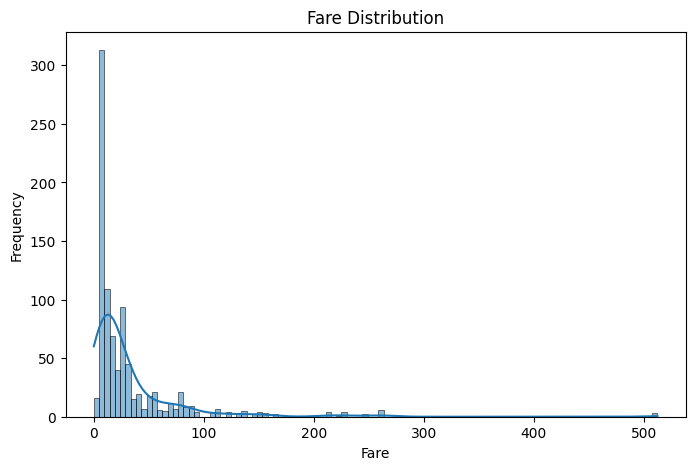


Survival by Gender:
Survived    0    1
Sex               
female     81  233
male      468  109

Survival by Passenger Class:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

Correlation Matrix:
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp       

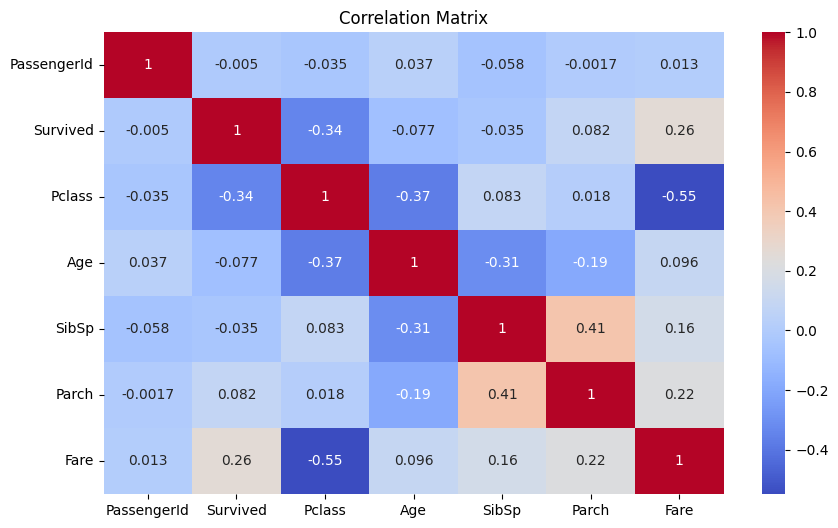

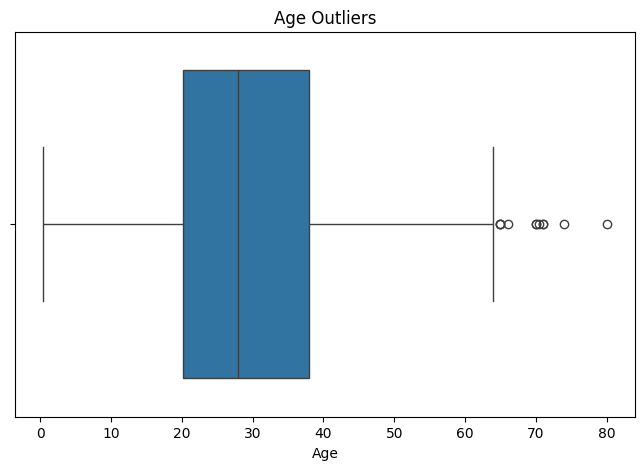

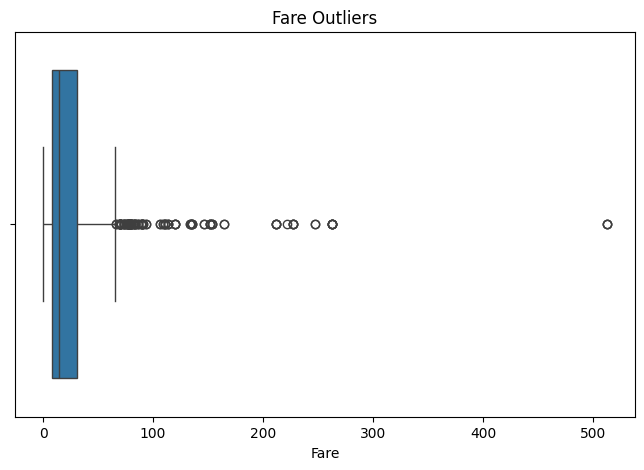


Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

===== KEY FINDINGS =====
Overall survival rate: 38.38%
Average passenger age: 29.70
Average ticket fare: 32.20
Female survival rate: 74.20%
Male survival rate: 18.89%

Short report saved as titanic_analysis_report.txt


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset directly
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")

# 1. Examine dataset
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

# 2. Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

# 3. Identify distributions
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Fare"], kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

# 4. Relationships between variables
print("\nSurvival by Gender:")
print(pd.crosstab(df["Sex"], df["Survived"]))

print("\nSurvival by Passenger Class:")
print(pd.crosstab(df["Pclass"], df["Survived"]))

# 5. Correlation
numeric_columns = df.select_dtypes(include="number")

print("\nCorrelation Matrix:")
print(numeric_columns.corr())

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_columns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 6. Detect outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Age"])
plt.title("Age Outliers")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()

# 7. Survival analysis
print("\nSurvival Count:")
print(df["Survived"].value_counts())

print("\nSurvival Percentage:")
print(df["Survived"].value_counts(normalize=True) * 100)

# 8. Business findings
survival_rate = df["Survived"].mean() * 100
female_survival = df[df["Sex"] == "female"]["Survived"].mean() * 100
male_survival = df[df["Sex"] == "male"]["Survived"].mean() * 100

print("\n===== KEY FINDINGS =====")
print(f"Overall survival rate: {survival_rate:.2f}%")
print(f"Average passenger age: {df['Age'].mean():.2f}")
print(f"Average ticket fare: {df['Fare'].mean():.2f}")
print(f"Female survival rate: {female_survival:.2f}%")
print(f"Male survival rate: {male_survival:.2f}%")

# 9. Short report
with open("titanic_analysis_report.txt", "w") as report:
    report.write("TITANIC DATA ANALYSIS REPORT\n")
    report.write("============================\n\n")
    report.write(f"Total records: {df.shape[0]}\n")
    report.write(f"Total features: {df.shape[1]}\n")
    report.write(f"Overall survival rate: {survival_rate:.2f}%\n")
    report.write(f"Average passenger age: {df['Age'].mean():.2f}\n")
    report.write(f"Average ticket fare: {df['Fare'].mean():.2f}\n")
    report.write(f"Female survival rate: {female_survival:.2f}%\n")
    report.write(f"Male survival rate: {male_survival:.2f}%\n")

print("\nShort report saved as titanic_analysis_report.txt")